# World Cup Match Outcome Modeling

This notebook builds match prediction model for international soccer.

It uses the cleaned `data/results.csv` file from the get-data notebook.

The goal is to predict match outcomes:

- `home_win`
- `draw`
- `away_win`

This is the modeling foundation for a future World Cup simulator.


## Modeling approach

This notebook uses two core ideas:

1. **Elo ratings**
   - Every national team starts at 1500
   - Ratings update chronologically after each match
   - Pre-match Elo difference becomes the main team-strength feature

2. **Recent form**
   - Rolling points per match
   - Rolling goals for
   - Rolling goals against
   - Calculated using only matches before the current match

Then we train two baseline models:

- **Multinomial Logistic Regression**
  - Best baseline for probabilities
  - Useful for simulation

- **Random Forest**
  - Captures nonlinear relationships
  - Useful comparison model


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import pickle

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)

DATA_DIR = Path.cwd() / "data"
MODEL_DIR = Path.cwd() / "models"
OUTPUT_DIR = Path.cwd() / "outputs"

DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Current working directory:", Path.cwd())
print("Data directory:", DATA_DIR)
print("Model directory:", MODEL_DIR)
print("Output directory:", OUTPUT_DIR)


c:\Users\conno\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\conno\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Current working directory: c:\Users\conno\OneDrive\Documents\World Cup Analytics
Data directory: c:\Users\conno\OneDrive\Documents\World Cup Analytics\data
Model directory: c:\Users\conno\OneDrive\Documents\World Cup Analytics\models
Output directory: c:\Users\conno\OneDrive\Documents\World Cup Analytics\outputs


## 1. Load cleaned match results

This notebook expects:

```text
data/results.csv
```

If you used the fixed get-data notebook, this file should already exist.


In [2]:
RESULTS_PATH = DATA_DIR / "results.csv"

if not RESULTS_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {RESULTS_PATH}. "
        "Run the fixed get-data notebook first and make sure it saves data/results.csv."
    )

matches = pd.read_csv(RESULTS_PATH)
matches["date"] = pd.to_datetime(matches["date"], errors="coerce")
matches = matches.sort_values("date").reset_index(drop=True)

print(matches.shape)
matches.head()


(49373, 12)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,goal_diff,total_goals
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,draw,0,0
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,home_win,2,6
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,home_win,1,3
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,draw,0,4
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,home_win,3,3


In [3]:
matches.info()


<class 'pandas.DataFrame'>
RangeIndex: 49373 entries, 0 to 49372
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         49373 non-null  datetime64[us]
 1   home_team    49373 non-null  str           
 2   away_team    49373 non-null  str           
 3   home_score   49373 non-null  int64         
 4   away_score   49373 non-null  int64         
 5   tournament   49373 non-null  str           
 6   city         49373 non-null  str           
 7   country      49373 non-null  str           
 8   neutral      49373 non-null  bool          
 9   result       49373 non-null  str           
 10  goal_diff    49373 non-null  int64         
 11  total_goals  49373 non-null  int64         
dtypes: bool(1), datetime64[us](1), int64(4), str(6)
memory usage: 6.9 MB


## 2. Validate and clean columns

We need these columns:

- `date`
- `home_team`
- `away_team`
- `home_score`
- `away_score`
- `tournament`
- `neutral`


In [4]:
required_cols = [
    "date",
    "home_team",
    "away_team",
    "home_score",
    "away_score",
    "tournament",
    "neutral"
]

missing_cols = [col for col in required_cols if col not in matches.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

matches = matches.dropna(subset=[
    "date", "home_team", "away_team", "home_score", "away_score"
]).copy()

matches["home_team"] = matches["home_team"].astype(str).str.strip()
matches["away_team"] = matches["away_team"].astype(str).str.strip()
matches["tournament"] = matches["tournament"].astype(str).str.strip()

matches["home_score"] = pd.to_numeric(matches["home_score"], errors="coerce")
matches["away_score"] = pd.to_numeric(matches["away_score"], errors="coerce")

matches = matches.dropna(subset=["home_score", "away_score"]).copy()

matches["home_score"] = matches["home_score"].astype(int)
matches["away_score"] = matches["away_score"].astype(int)

matches["neutral"] = matches["neutral"].astype(bool)

matches["result"] = np.select(
    [
        matches["home_score"] > matches["away_score"],
        matches["home_score"] == matches["away_score"],
        matches["home_score"] < matches["away_score"],
    ],
    ["home_win", "draw", "away_win"]
)

matches["goal_diff"] = matches["home_score"] - matches["away_score"]
matches["total_goals"] = matches["home_score"] + matches["away_score"]

matches = matches.sort_values("date").reset_index(drop=True)

matches[["date", "home_team", "away_team", "home_score", "away_score", "result", "tournament", "neutral"]].head()


,date,home_team,away_team,home_score,away_score,result,tournament,neutral
0,1872-11-30,Scotland,England,0,0,draw,Friendly,False
1,1873-03-08,England,Scotland,4,2,home_win,Friendly,False
2,1874-03-07,Scotland,England,2,1,home_win,Friendly,False
3,1875-03-06,England,Scotland,2,2,draw,Friendly,False
4,1876-03-04,Scotland,England,3,0,home_win,Friendly,False


In [5]:
print("Date range:", matches["date"].min(), "to", matches["date"].max())
print("Rows:", len(matches))
print("Teams:", pd.concat([matches["home_team"], matches["away_team"]]).nunique())

print("\nResult distribution:")
print(matches["result"].value_counts(normalize=True).round(3))


Date range: 1872-11-30 00:00:00 to 2026-06-07 00:00:00
Rows: 49373
Teams: 336

Result distribution:
result
home_win    0.490
away_win    0.283
draw        0.227
Name: proportion, dtype: float64


## 3. Build Elo features

Elo is a rolling team-strength rating.

For each match, we store:

- home team's Elo before the match
- away team's Elo before the match
- Elo difference

Then we update ratings after the match.

This is important because we do not want to use future information.


In [6]:
def expected_score(rating_a, rating_b):
    """Expected score for Team A against Team B."""
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))


def margin_multiplier(goal_diff):
    """Make big wins count slightly more without overreacting."""
    gd = abs(goal_diff)
    if gd <= 1:
        return 1.0
    return np.log(gd + 1)


def get_k_factor(tournament):
    """Simple tournament importance weighting."""
    t = str(tournament).lower()

    if "fifa world cup" in t and "qualification" not in t and "qualifier" not in t:
        return 60
    elif "qualification" in t or "qualifier" in t:
        return 40
    elif "friendly" in t:
        return 20
    else:
        return 30


def build_elo_features(df, starting_elo=1500):
    df = df.sort_values("date").copy().reset_index(drop=True)

    ratings = {}
    home_elos = []
    away_elos = []
    k_factors = []

    for _, row in df.iterrows():
        home = row["home_team"]
        away = row["away_team"]

        home_rating = ratings.get(home, starting_elo)
        away_rating = ratings.get(away, starting_elo)

        home_elos.append(home_rating)
        away_elos.append(away_rating)

        if row["home_score"] > row["away_score"]:
            actual_home = 1.0
        elif row["home_score"] == row["away_score"]:
            actual_home = 0.5
        else:
            actual_home = 0.0

        exp_home = expected_score(home_rating, away_rating)
        exp_away = 1 - exp_home

        k = get_k_factor(row["tournament"])
        mov = margin_multiplier(row["home_score"] - row["away_score"])
        k_factors.append(k)

        new_home_rating = home_rating + k * mov * (actual_home - exp_home)
        new_away_rating = away_rating + k * mov * ((1 - actual_home) - exp_away)

        ratings[home] = new_home_rating
        ratings[away] = new_away_rating

    df["home_elo_pre"] = home_elos
    df["away_elo_pre"] = away_elos
    df["elo_diff"] = df["home_elo_pre"] - df["away_elo_pre"]
    df["elo_abs_diff"] = df["elo_diff"].abs()
    df["elo_k_factor"] = k_factors

    return df, ratings


matches_elo, current_elo_ratings = build_elo_features(matches)

matches_elo[[
    "date", "home_team", "away_team", "home_score", "away_score",
    "home_elo_pre", "away_elo_pre", "elo_diff", "result"
]].tail()


,date,home_team,away_team,home_score,away_score,home_elo_pre,away_elo_pre,elo_diff,result
49368,2026-06-07,Morocco,Norway,1,1,1974.025155,1920.364971,53.660183,draw
49369,2026-06-07,Kosovo,Andorra,3,0,1726.637627,1176.032189,550.605439,home_win
49370,2026-06-07,Liechtenstein,Cyprus,0,2,1056.099749,1398.712158,-342.612409,away_win
49371,2026-06-07,Greece,Italy,0,1,1782.087108,1904.662590,-122.575482,away_win
49372,2026-06-07,Denmark,Ukraine,2,1,1878.510915,1800.974776,77.536139,home_win


In [7]:
elo_table = (
    pd.DataFrame({
        "team": list(current_elo_ratings.keys()),
        "elo": list(current_elo_ratings.values())
    })
    .sort_values("elo", ascending=False)
    .reset_index(drop=True)
)

elo_table.head(25)


,team,elo
0,Spain,2123.711856
1,Argentina,2103.762639
2,France,2076.037610
3,England,2033.808661
4,Portugal,2004.895160
5,Germany,2003.570436
6,Brazil,1998.661838
7,Colombia,1986.720316
8,Japan,1983.284960
9,Netherlands,1981.282099


## 4. Build recent-form features

For each team, calculate stats from its previous 5 matches:

- points per match
- goals for per match
- goals against per match
- goal difference per match

This gives the model a short-term form signal.


In [8]:
def add_recent_form_features(df, window=5):
    df = df.sort_values("date").copy().reset_index(drop=True)

    team_history = {}

    home_pts_avg = []
    away_pts_avg = []
    home_gf_avg = []
    away_gf_avg = []
    home_ga_avg = []
    away_ga_avg = []
    home_gd_avg = []
    away_gd_avg = []
    home_matches_played = []
    away_matches_played = []

    def summarize(history):
        recent = history[-window:]
        if len(recent) == 0:
            return np.nan, np.nan, np.nan, np.nan, 0

        pts = np.mean([x["points"] for x in recent])
        gf = np.mean([x["gf"] for x in recent])
        ga = np.mean([x["ga"] for x in recent])
        gd = np.mean([x["gf"] - x["ga"] for x in recent])
        played = len(history)

        return pts, gf, ga, gd, played

    for _, row in df.iterrows():
        home = row["home_team"]
        away = row["away_team"]

        h_pts, h_gf, h_ga, h_gd, h_played = summarize(team_history.get(home, []))
        a_pts, a_gf, a_ga, a_gd, a_played = summarize(team_history.get(away, []))

        home_pts_avg.append(h_pts)
        away_pts_avg.append(a_pts)
        home_gf_avg.append(h_gf)
        away_gf_avg.append(a_gf)
        home_ga_avg.append(h_ga)
        away_ga_avg.append(a_ga)
        home_gd_avg.append(h_gd)
        away_gd_avg.append(a_gd)
        home_matches_played.append(h_played)
        away_matches_played.append(a_played)

        if row["home_score"] > row["away_score"]:
            home_points, away_points = 3, 0
        elif row["home_score"] == row["away_score"]:
            home_points, away_points = 1, 1
        else:
            home_points, away_points = 0, 3

        team_history.setdefault(home, []).append({
            "points": home_points,
            "gf": row["home_score"],
            "ga": row["away_score"],
        })

        team_history.setdefault(away, []).append({
            "points": away_points,
            "gf": row["away_score"],
            "ga": row["home_score"],
        })

    df["home_form_pts_5"] = home_pts_avg
    df["away_form_pts_5"] = away_pts_avg
    df["form_pts_diff_5"] = df["home_form_pts_5"] - df["away_form_pts_5"]

    df["home_gf_avg_5"] = home_gf_avg
    df["away_gf_avg_5"] = away_gf_avg
    df["gf_avg_diff_5"] = df["home_gf_avg_5"] - df["away_gf_avg_5"]

    df["home_ga_avg_5"] = home_ga_avg
    df["away_ga_avg_5"] = away_ga_avg
    df["ga_avg_diff_5"] = df["home_ga_avg_5"] - df["away_ga_avg_5"]

    df["home_gd_avg_5"] = home_gd_avg
    df["away_gd_avg_5"] = away_gd_avg
    df["gd_avg_diff_5"] = df["home_gd_avg_5"] - df["away_gd_avg_5"]

    df["home_matches_played_pre"] = home_matches_played
    df["away_matches_played_pre"] = away_matches_played
    df["matches_played_diff_pre"] = df["home_matches_played_pre"] - df["away_matches_played_pre"]

    return df


model_df = add_recent_form_features(matches_elo, window=5)

model_df[[
    "date", "home_team", "away_team", "result",
    "elo_diff", "form_pts_diff_5", "gf_avg_diff_5", "ga_avg_diff_5", "gd_avg_diff_5"
]].tail()


,date,home_team,away_team,result,elo_diff,form_pts_diff_5,gf_avg_diff_5,ga_avg_diff_5,gd_avg_diff_5
49368,2026-06-07,Greece,Italy,away_win,-122.575482,-0.8,-0.4,0.0,-0.4
49369,2026-06-07,Ecuador,Guatemala,home_win,340.933077,0.6,-0.2,-2.6,2.4
49370,2026-06-07,Croatia,Slovenia,home_win,215.581774,0.8,0.8,0.4,0.4
49371,2026-06-07,Jordan,Colombia,away_win,-232.645273,-0.8,-0.4,0.8,-1.2
49372,2026-06-07,Denmark,Ukraine,home_win,77.536139,-0.6,0.8,0.2,0.6


## 5. Add tournament flags

These context features help separate friendlies, qualifiers, and World Cup matches.


In [9]:
tournament_lower = model_df["tournament"].str.lower()

model_df["is_world_cup"] = (
    tournament_lower.str.contains("fifa world cup", na=False)
    & ~tournament_lower.str.contains("qualification|qualifier", na=False)
)

model_df["is_qualifier"] = tournament_lower.str.contains("qualification|qualifier", na=False)
model_df["is_friendly"] = tournament_lower.str.contains("friendly", na=False)

model_df[["tournament", "is_world_cup", "is_qualifier", "is_friendly"]].drop_duplicates().head(20)


,tournament,is_world_cup,is_qualifier,is_friendly
0,Friendly,False,False,True
29,British Home Championship,False,False,False
163,Évence Coppée Trophy,False,False,False
174,Muratti Vase,False,False,False
180,Copa Lipton,False,False,False
196,Copa Newton,False,False,False
237,Copa Premio Honor Argentino,False,False,False
238,Olympic Games,False,False,False
320,Copa Premio Honor Uruguayo,False,False,False
385,Far Eastern Championship Games,False,False,False


## 6. Time-based train/test split

Because this is historical sports data, a random split is misleading.

We train on older matches and test on newer matches.

The default split:
- Train: before 2018
- Test: 2018 and later

You can adjust `cutoff_date`.


In [10]:
cutoff_date = pd.Timestamp("2018-01-01")

train_df = model_df[model_df["date"] < cutoff_date].copy()
test_df = model_df[model_df["date"] >= cutoff_date].copy()

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train date range:", train_df["date"].min(), "to", train_df["date"].max())
print("Test date range:", test_df["date"].min(), "to", test_df["date"].max())

print("\nTrain result distribution:")
print(train_df["result"].value_counts(normalize=True).round(3))

print("\nTest result distribution:")
print(test_df["result"].value_counts(normalize=True).round(3))


Train rows: 41297
Test rows: 8076
Train date range: 1872-11-30 00:00:00 to 2017-12-29 00:00:00
Test date range: 2018-01-02 00:00:00 to 2026-06-07 00:00:00

Train result distribution:
result
home_win    0.493
away_win    0.281
draw        0.227
Name: proportion, dtype: float64

Test result distribution:
result
home_win    0.478
away_win    0.292
draw        0.231
Name: proportion, dtype: float64


## 7. Define features and target

In [11]:
numeric_features = [
    "home_elo_pre",
    "away_elo_pre",
    "elo_diff",
    "elo_abs_diff",
    "home_form_pts_5",
    "away_form_pts_5",
    "form_pts_diff_5",
    "home_gf_avg_5",
    "away_gf_avg_5",
    "gf_avg_diff_5",
    "home_ga_avg_5",
    "away_ga_avg_5",
    "ga_avg_diff_5",
    "home_gd_avg_5",
    "away_gd_avg_5",
    "gd_avg_diff_5",
    "home_matches_played_pre",
    "away_matches_played_pre",
    "matches_played_diff_pre",
]

# Convert boolean columns to integers
bool_cols = [
    "neutral",
    "is_world_cup",
    "is_qualifier",
    "is_friendly",
]

for col in bool_cols:
    model_df[col] = model_df[col].astype(int)

categorical_features = []

numeric_features.extend(bool_cols)

target = "result"

X_train = train_df[numeric_features + categorical_features]
y_train = train_df[target]

X_test = test_df[numeric_features + categorical_features]
y_test = test_df[target]

X_train.head()


,home_elo_pre,away_elo_pre,elo_diff,elo_abs_diff,home_form_pts_5,away_form_pts_5,form_pts_diff_5,home_gf_avg_5,away_gf_avg_5,gf_avg_diff_5,home_ga_avg_5,away_ga_avg_5,ga_avg_diff_5,home_gd_avg_5,away_gd_avg_5,gd_avg_diff_5,home_matches_played_pre,away_matches_played_pre,matches_played_diff_pre,neutral,is_world_cup,is_qualifier,is_friendly
0,1500.000000,1500.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,False,False,False,True
1,1500.000000,1500.000000,0.000000,0.000000,1.000000,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,1,0,False,False,False,True
2,1489.013877,1510.986123,-21.972246,21.972246,0.500000,2.000000,-1.5,1.000000,2.000000,-1.000000,2.000000,1.000000,1.000000,-1.000000,1.000000,-2.000000,2,2,0,False,False,False,True
3,1500.354553,1499.645447,0.709105,0.709105,1.333333,1.333333,0.0,1.666667,1.333333,0.333333,1.333333,1.666667,-0.333333,0.333333,-0.333333,0.666667,3,3,0,False,False,False,True
4,1499.665857,1500.334143,-0.668286,0.668286,1.250000,1.250000,0.0,1.500000,1.750000,-0.250000,1.750000,1.500000,0.250000,-0.250000,0.250000,-0.500000,4,4,0,False,False,False,True


## 8. Build preprocessing pipeline

Numeric features:
- missing values filled with median
- standardized

Categorical features:
- missing values filled with most common value
- one-hot encoded


In [12]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


## 9. Model 1: Multinomial Logistic Regression

Good baseline for World Cup simulator because it produces clean probabilities.


In [13]:
log_reg = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
    max_iter=3000,
    multi_class="multinomial",
    class_weight={
        "home_win": 1.0,
        "draw": 1.5, # Slightly upweight draws to improve calibration on that class
        "away_win": 1.0
    },
    random_state=42
    ))
])

log_reg.fit(X_train, y_train)

log_reg_preds = log_reg.predict(X_test)
log_reg_probs = log_reg.predict_proba(X_test)

print("Logistic Regression")
print("Accuracy:", round(accuracy_score(y_test, log_reg_preds), 4))
print("Log Loss:", round(log_loss(y_test, log_reg_probs, labels=log_reg.classes_), 4))
print()
print(classification_report(y_test, log_reg_preds))


c:\Users\conno\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression
Accuracy: 0.5769
Log Loss: 0.8826

              precision    recall  f1-score   support

    away_win       0.64      0.48      0.55      2357
        draw       0.31      0.31      0.31      1862
    home_win       0.67      0.76      0.71      3857

    accuracy                           0.58      8076
   macro avg       0.54      0.52      0.52      8076
weighted avg       0.58      0.58      0.57      8076



## 10. Model 2: Random Forest


In [14]:
rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=20,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)

print("Random Forest")
print("Accuracy:", round(accuracy_score(y_test, rf_preds), 4))
print("Log Loss:", round(log_loss(y_test, rf_probs, labels=rf.classes_), 4))
print()
print(classification_report(y_test, rf_preds))


Random Forest
Accuracy: 0.5711
Log Loss: 0.8972

              precision    recall  f1-score   support

    away_win       0.57      0.63      0.59      2357
        draw       0.30      0.29      0.29      1862
    home_win       0.71      0.67      0.69      3857

    accuracy                           0.57      8076
   macro avg       0.52      0.53      0.53      8076
weighted avg       0.57      0.57      0.57      8076



## 11. Compare models

In [15]:
model_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "accuracy": accuracy_score(y_test, log_reg_preds),
        "log_loss": log_loss(y_test, log_reg_probs, labels=log_reg.classes_)
    },
    {
        "model": "Random Forest",
        "accuracy": accuracy_score(y_test, rf_preds),
        "log_loss": log_loss(y_test, rf_probs, labels=rf.classes_)
    }
]).sort_values("log_loss")

model_comparison


,model,accuracy,log_loss
0,Logistic Regression,0.576895,0.882596
1,Random Forest,0.571075,0.897188


## 12. Confusion matrix

In [16]:
labels = ["home_win", "draw", "away_win"]

cm = confusion_matrix(y_test, log_reg_preds, labels=labels)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {label}" for label in labels],
    columns=[f"Predicted {label}" for label in labels]
)

cm_df


,Predicted home_win,Predicted draw,Predicted away_win
Actual home_win,2940,669,248
Actual draw,900,577,385
Actual away_win,575,640,1142


## 13. Create prediction dataframe

In [17]:
predictions = test_df[[
    "date",
    "home_team",
    "away_team",
    "home_score",
    "away_score",
    "result",
    "tournament",
    "neutral",
    "home_elo_pre",
    "away_elo_pre",
    "elo_diff"
]].copy()

for i, class_name in enumerate(log_reg.classes_):
    predictions[f"prob_{class_name}"] = log_reg_probs[:, i]

predictions["predicted_result"] = log_reg_preds
predictions["max_probability"] = log_reg_probs.max(axis=1)
predictions["correct"] = predictions["predicted_result"] == predictions["result"]

predictions.sort_values("max_probability", ascending=False).head(20)


,date,home_team,away_team,home_score,away_score,result,tournament,neutral,home_elo_pre,away_elo_pre,elo_diff,prob_away_win,prob_draw,prob_home_win,predicted_result,max_probability,correct
43033,2019-10-10,Belgium,San Marino,9,0,home_win,UEFA Euro qualification,False,2084.390686,954.548918,1129.841768,0.000105,0.004302,0.995593,home_win,0.995593,True
44529,2021-10-09,Poland,San Marino,5,0,home_win,FIFA World Cup qualification,False,1831.565273,941.700382,889.864891,0.000466,0.008870,0.990664,home_win,0.990664,True
43777,2021-03-25,England,San Marino,5,0,home_win,FIFA World Cup qualification,False,1989.220979,958.024112,1031.196867,0.000345,0.012403,0.987252,home_win,0.987252,True
46745,2023-11-18,France,Gibraltar,14,0,home_win,UEFA Euro qualification,False,2135.424953,1194.671794,940.753159,0.000487,0.012867,0.986647,home_win,0.986647,True
48718,2025-10-09,Austria,San Marino,10,0,home_win,FIFA World Cup qualification,False,1878.294891,955.471807,922.823085,0.000588,0.013929,0.985483,home_win,0.985483,True
44076,2021-06-09,South Korea,Sri Lanka,5,0,home_win,FIFA World Cup qualification,False,1826.083217,974.264740,851.818478,0.000754,0.014371,0.984875,home_win,0.984875,True
43926,2021-05-28,Italy,San Marino,7,0,home_win,Friendly,False,1993.108524,956.151180,1036.957344,0.000426,0.014830,0.984744,home_win,0.984744,True
46322,2023-09-07,Denmark,San Marino,4,0,home_win,UEFA Euro qualification,False,1862.935510,922.746200,940.189310,0.000607,0.015015,0.984378,home_win,0.984378,True
48988,2025-11-18,Belgium,Liechtenstein,7,0,home_win,FIFA World Cup qualification,False,1904.021630,1050.740250,853.281380,0.000772,0.015038,0.984190,home_win,0.984190,True
44722,2021-11-15,San Marino,England,0,10,away_win,FIFA World Cup qualification,False,927.578603,2043.875825,-1116.297221,0.984089,0.015569,0.000343,away_win,0.984089,True


In [18]:
predictions[predictions["correct"] == False].sort_values("max_probability", ascending=False).head(20)


,date,home_team,away_team,home_score,away_score,result,tournament,neutral,home_elo_pre,away_elo_pre,elo_diff,prob_away_win,prob_draw,prob_home_win,predicted_result,max_probability,correct
47234,2024-06-06,Gibraltar,Wales,0,0,draw,Friendly,True,1178.264805,1785.735036,-607.470231,0.929492,0.065161,0.005347,away_win,0.929492,False
47157,2024-03-26,Brunei,Vanuatu,3,2,home_win,FIFA Series,True,897.523051,1461.290883,-563.767832,0.926963,0.060640,0.012397,away_win,0.926963,False
47268,2024-06-07,Romania,Liechtenstein,0,0,draw,Friendly,False,1718.143126,1081.060277,637.082849,0.006075,0.070920,0.923005,home_win,0.923005,False
43882,2021-03-30,Senegal,Eswatini,1,1,draw,African Cup of Nations qualification,False,1806.913090,1248.223127,558.689963,0.007766,0.070212,0.922022,home_win,0.922022,False
48934,2025-11-15,Denmark,Belarus,2,2,draw,FIFA World Cup qualification,False,1923.029664,1493.744409,429.285255,0.009355,0.073448,0.917197,home_win,0.917197,False
42912,2019-09-08,Greece,Liechtenstein,1,1,draw,UEFA Euro qualification,False,1616.110042,1197.158627,418.951414,0.013209,0.076552,0.910239,home_win,0.910239,False
49024,2025-11-26,Oman,Somalia,0,0,draw,Arab Cup qualification,True,1617.477434,1053.541595,563.935839,0.011712,0.080515,0.907773,home_win,0.907773,False
47962,2024-11-17,Thailand,Laos,1,1,draw,Friendly,False,1589.276199,979.028929,610.247271,0.008023,0.085377,0.906600,home_win,0.906600,False
48052,2024-12-12,Indonesia,Laos,3,3,draw,ASEAN Championship,False,1541.083011,985.775708,555.307303,0.010483,0.083051,0.906466,home_win,0.906466,False
48956,2025-11-17,Bahrain,Somalia,1,2,away_win,Friendly,False,1575.289664,1034.392545,540.897118,0.009398,0.086711,0.903891,home_win,0.903891,False


## 14. Random Forest feature importance

In [19]:
rf_preprocessor = rf.named_steps["preprocess"]
rf_model = rf.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()
feature_importances = rf_model.feature_importances_

feature_importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": feature_importances
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance_df.head(25)


,feature,importance
0,num__elo_diff,0.204457
1,num__elo_abs_diff,0.090696
2,num__matches_played_diff_pre,0.082746
3,num__away_elo_pre,0.082266
4,num__home_elo_pre,0.072005
5,num__away_matches_played_pre,0.053183
6,num__gd_avg_diff_5,0.052374
7,num__home_matches_played_pre,0.048013
8,num__ga_avg_diff_5,0.042112
9,num__home_gd_avg_5,0.029650


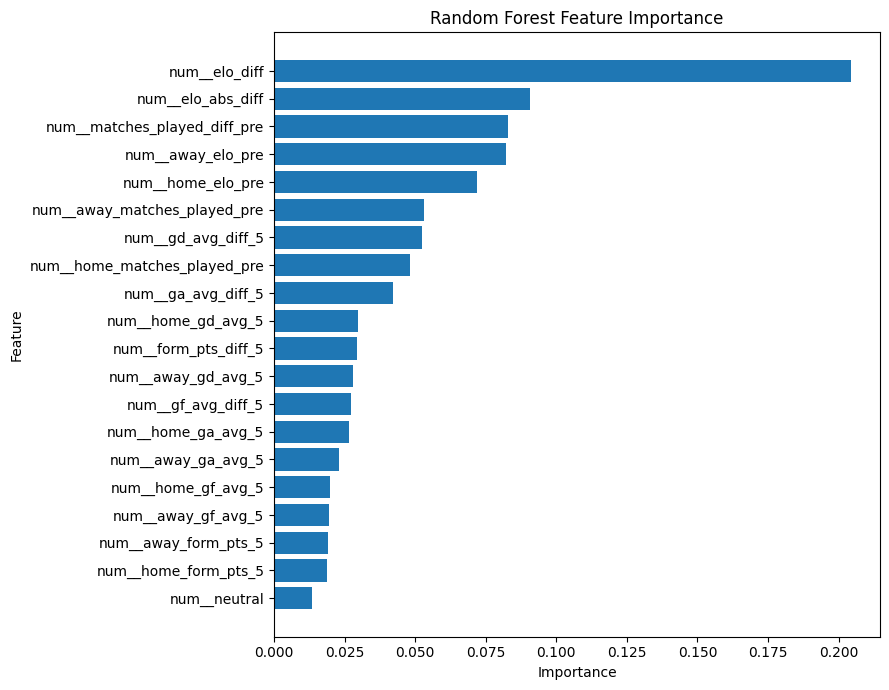

In [20]:
top_n = 20
plot_df = feature_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(9, 7))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 15. Logistic regression coefficients


In [21]:
log_reg_preprocessor = log_reg.named_steps["preprocess"]
log_reg_model = log_reg.named_steps["model"]

coef_feature_names = log_reg_preprocessor.get_feature_names_out()

coef_df = pd.DataFrame(
    log_reg_model.coef_,
    columns=coef_feature_names,
    index=log_reg_model.classes_
).T.reset_index().rename(columns={"index": "feature"})

coef_df.head()


,feature,away_win,draw,home_win
0,num__home_elo_pre,-0.208568,-0.011671,0.220239
1,num__away_elo_pre,0.207868,0.012480,-0.220347
2,num__elo_diff,-0.371516,-0.021549,0.393065
3,num__elo_abs_diff,0.030155,-0.044558,0.014403
4,num__home_form_pts_5,0.007897,0.021696,-0.029592


## 16. Save outputs

This saves:

- model-ready dataset
- Elo ratings
- test predictions
- model comparison
- feature importance
- logistic regression model
- random forest model


In [22]:
model_df.to_csv(DATA_DIR / "model_ready_matches.csv", index=False)
elo_table.to_csv(DATA_DIR / "elo_table.csv", index=False)

predictions.to_csv(OUTPUT_DIR / "test_predictions_logistic_regression.csv", index=False)
model_comparison.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
feature_importance_df.to_csv(OUTPUT_DIR / "random_forest_feature_importance.csv", index=False)
coef_df.to_csv(OUTPUT_DIR / "logistic_regression_coefficients.csv", index=False)

with open(MODEL_DIR / "logistic_regression_match_model.pkl", "wb") as f:
    pickle.dump(log_reg, f)

with open(MODEL_DIR / "random_forest_match_model.pkl", "wb") as f:
    pickle.dump(rf, f)

print("Saved files:")
print(DATA_DIR / "model_ready_matches.csv")
print(DATA_DIR / "elo_table.csv")
print(OUTPUT_DIR / "test_predictions_logistic_regression.csv")
print(OUTPUT_DIR / "model_comparison.csv")
print(OUTPUT_DIR / "random_forest_feature_importance.csv")
print(OUTPUT_DIR / "logistic_regression_coefficients.csv")
print(MODEL_DIR / "logistic_regression_match_model.pkl")
print(MODEL_DIR / "random_forest_match_model.pkl")


Saved files:
c:\Users\conno\OneDrive\Documents\World Cup Analytics\data\model_ready_matches.csv
c:\Users\conno\OneDrive\Documents\World Cup Analytics\data\elo_table.csv
c:\Users\conno\OneDrive\Documents\World Cup Analytics\outputs\test_predictions_logistic_regression.csv
c:\Users\conno\OneDrive\Documents\World Cup Analytics\outputs\model_comparison.csv
c:\Users\conno\OneDrive\Documents\World Cup Analytics\outputs\random_forest_feature_importance.csv
c:\Users\conno\OneDrive\Documents\World Cup Analytics\outputs\logistic_regression_coefficients.csv
c:\Users\conno\OneDrive\Documents\World Cup Analytics\models\logistic_regression_match_model.pkl
c:\Users\conno\OneDrive\Documents\World Cup Analytics\models\random_forest_match_model.pkl
